In [20]:
#1: Load Libraries & Data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore, skew, kurtosis
from scipy.stats import boxcox

# Load dataset
df = pd.read_csv("house_price.csv")  
# Display first few rows
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [16]:
#2: Basic EDA
# Check missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 location          0
size              0
total_sqft        0
bath              0
price             0
bhk               0
price_per_sqft    0
dtype: int64


In [18]:
# Summary statistics
print("\nSummary Statistics:\n", df.describe())


Summary Statistics:
          total_sqft          bath         price           bhk  price_per_sqft
count  13200.000000  13200.000000  13200.000000  13200.000000    1.320000e+04
mean    1555.302783      2.691136    112.276178      2.800833    7.920337e+03
std     1237.323445      1.338915    149.175995      1.292843    1.067272e+05
min        1.000000      1.000000      8.000000      1.000000    2.670000e+02
25%     1100.000000      2.000000     50.000000      2.000000    4.267000e+03
50%     1275.000000      2.000000     71.850000      3.000000    5.438000e+03
75%     1672.000000      3.000000    120.000000      3.000000    7.317000e+03
max    52272.000000     40.000000   3600.000000     43.000000    1.200000e+07


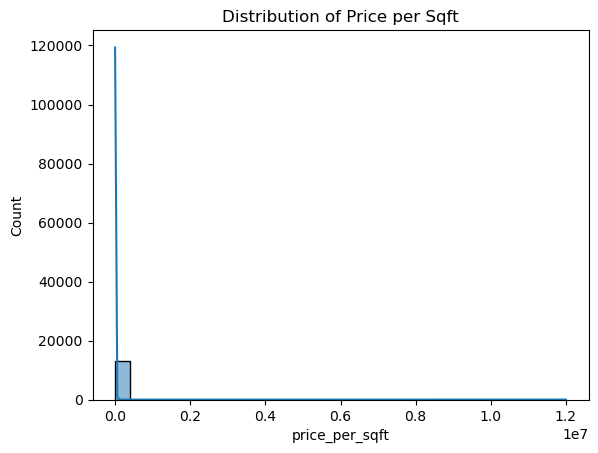

In [19]:
# Histogram of price per sqft
sns.histplot(df["price_per_sqft"], bins=30, kde=True)
plt.title("Distribution of Price per Sqft")
plt.show()

In [33]:
#3: Outlier Detection & Removal
#a: Mean & Standard Deviation
mean = df["price_per_sqft"].mean()
mean

7920.336742424242

In [34]:
std_dev = df["price_per_sqft"].std()
std_dev

106727.16032810845

In [37]:
threshold = 3  

df_filtered_std = df[(df["price_per_sqft"] >= mean - threshold * std_dev) & (df["price_per_sqft"] <= mean + threshold * std_dev)]
df_filtered_std

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
...,...,...,...,...,...,...,...
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689
13196,other,4 BHK,3600.0,5.0,400.00,4,11111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258
13198,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407


In [49]:
#b: Percentile Method
low, high = np.percentile(df["price_per_sqft"], [5, 95])  # Trimming extreme 1% values
df_filtered_percentile = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]


In [50]:
#c: IQR Method
Q1 = df["price_per_sqft"].quantile(0.25)
Q3 = df["price_per_sqft"].quantile(0.75)
IQR = Q3 - Q1

df_filtered_IQR = df[(df["price_per_sqft"] >= Q1 - 1.5 * IQR) & (df["price_per_sqft"] <= Q3 + 1.5 * IQR)]


In [51]:
#d: Z-Score Method
df["z_score"] = zscore(df["price_per_sqft"])
df_filtered_zscore = df[abs(df["z_score"]) < 3]
df.drop(columns=["z_score"], inplace=True)  # Drop temporary column


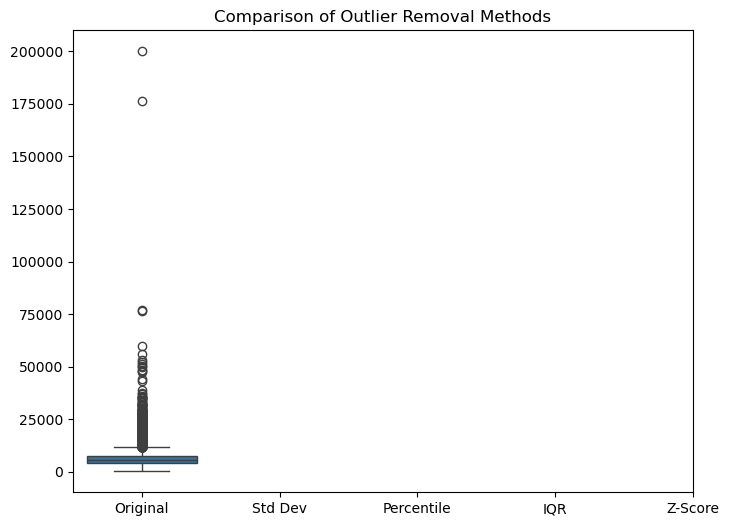

In [52]:
# 4: Box Plot (Compare Outlier Removal Methods)
plt.figure(figsize=(8, 6))
sns.boxplot(data=[df["price_per_sqft"], df_filtered_std["price_per_sqft"], df_filtered_percentile["price_per_sqft"],
                  df_filtered_IQR["price_per_sqft"], df_filtered_zscore["price_per_sqft"]])
plt.xticks([0, 1, 2, 3, 4], ["Original", "Std Dev", "Percentile", "IQR", "Z-Score"])
plt.title("Comparison of Outlier Removal Methods")
plt.show()


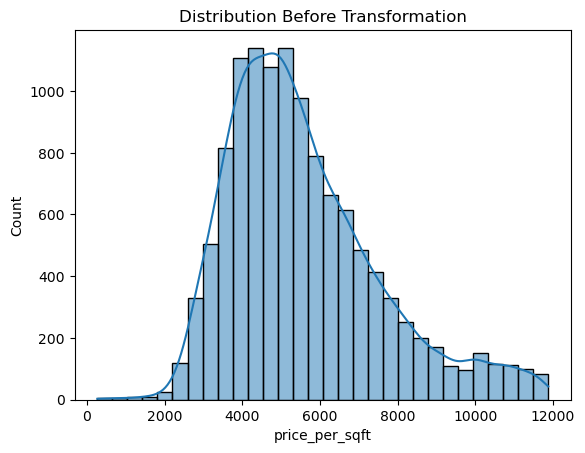

Before Transformation - Skewness: 0.9445732298531184
Before Transformation - Kurtosis: 0.6784399584501744


In [54]:
#5: Check Normality (Histogram + Transformation)
# Histogram before transformation
sns.histplot(df_filtered_IQR["price_per_sqft"], bins=30, kde=True)
plt.title("Distribution Before Transformation")
plt.show()

# Skewness & Kurtosis before transformation
print("Before Transformation - Skewness:", skew(df_filtered_IQR["price_per_sqft"]))
print("Before Transformation - Kurtosis:", kurtosis(df_filtered_IQR["price_per_sqft"]))


In [55]:
# Apply log transformation
df_filtered_IQR = df_filtered_IQR.copy()
df_filtered_IQR.loc[:, "price_per_sqft_log"] = np.log1p(df_filtered_IQR["price_per_sqft"])


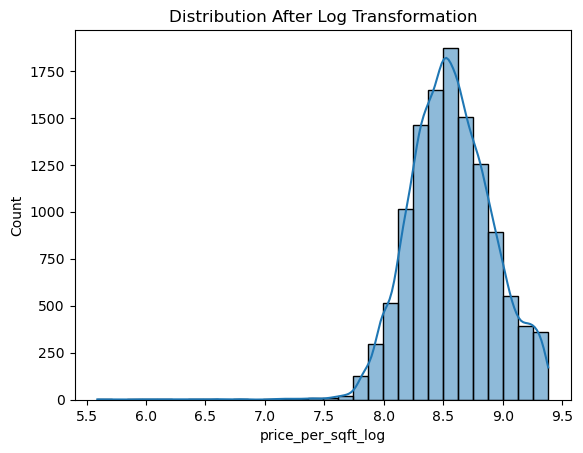

After Log Transformation - Skewness: -0.12988210833124453
After Log Transformation - Kurtosis: 1.3369230684904956


In [56]:
# Histogram after transformation
sns.histplot(df_filtered_IQR["price_per_sqft_log"], bins=30, kde=True)
plt.title("Distribution After Log Transformation")
plt.show()

# Skewness & Kurtosis after transformation
print("After Log Transformation - Skewness:", skew(df_filtered_IQR["price_per_sqft_log"]))
print("After Log Transformation - Kurtosis:", kurtosis(df_filtered_IQR["price_per_sqft_log"]))


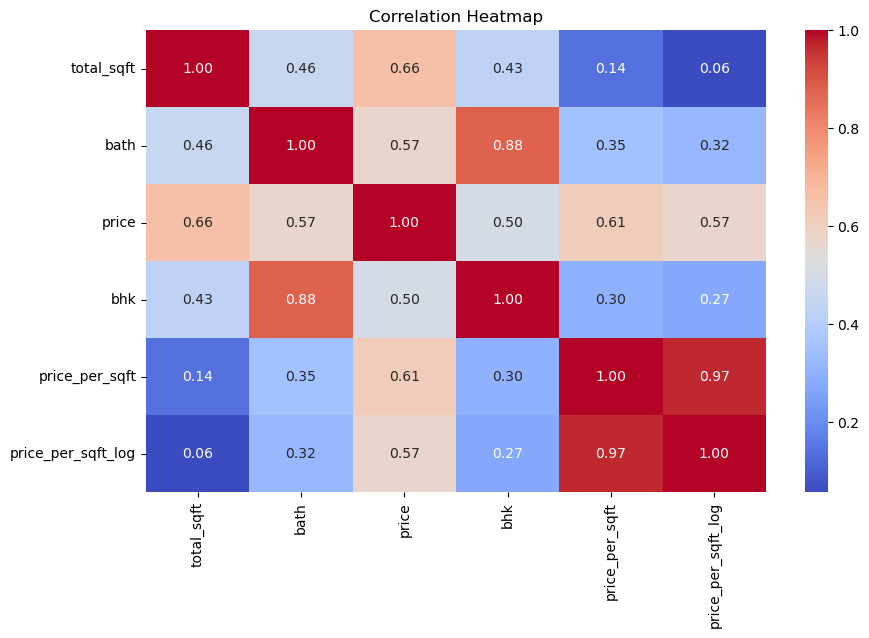

In [48]:
#6: Correlation Analysis & Heatmap
# Selecting only numeric columns before computing correlation
numeric_df = df_filtered_IQR.select_dtypes(include=[np.number])  # Exclude non-numeric columns
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


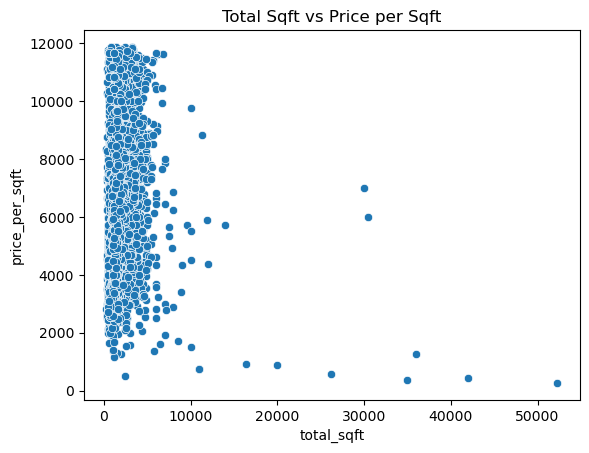

In [58]:
#7: Scatter Plot Analysis
# Scatter plot between price_per_sqft and total_sqft 
sns.scatterplot(x=df_filtered_IQR["total_sqft"], y=df_filtered_IQR["price_per_sqft"])
plt.title("Total Sqft vs Price per Sqft")
plt.show()
